# Quickstart


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

rng = np.random.default_rng(0)
N = 20_000

data = {
    "mass_1": rng.normal(30, 4, N),
    "mass_2": rng.normal(25, 3, N),
    "chi":    rng.uniform(-1, 1, N),
}

## First plot

[`corner()`](../api.md#cornerdata-kwargs) takes a `dict[str, array]` and returns a standard `(fig, axes)` pair.


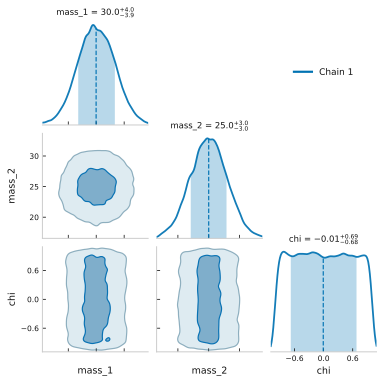

In [2]:
from cornetto import corner

fig, axes = corner(data, chain_labels=["Chain 1"])
plt.show()

## Labels and truth markers

Pass `labels` as a `dict[str, str]` - LaTeX via raw strings works out of the box.
Pass `truths` as a `dict[str, scalar]` for crosshairs.


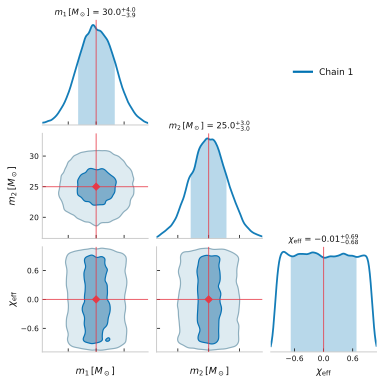

In [4]:
labels = {
    "mass_1": r"$m_1\,[M_\odot]$",
    "mass_2": r"$m_2\,[M_\odot]$",
    "chi":    r"$\chi_{\mathrm{eff}}$",
}

fig, axes = corner(
    data,
    labels=labels,
    truths={"mass_1": 30.0, "mass_2": 25., "chi": 0.0},
    chain_labels=["Chain 1"],
)
plt.show()

> Crosshairs properties can be set via the parameter `kwargs_truths`, a dictionary with: `color`, `lw`, `ls`, `alpha`, `marker`, and `markersize`.

## Two-chain comparison

Pass a 2-D `(N_chains, N_samples)` array for each parameter and `chain_labels` to name them in the legend.


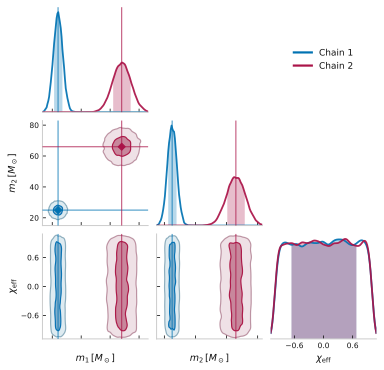

In [8]:
data_2 = {
    "mass_1": np.stack([rng.normal(30, 4, N), rng.normal(85, 8, N)]),
    "mass_2": np.stack([rng.normal(25, 3, N), rng.normal(66, 6, N)]),
    "chi":    np.stack([rng.uniform(-1, 1, N), rng.uniform(-1, 1, N)]),
}

labels_2 = {
    "mass_1": r"$m_1\,[M_\odot]$",
    "mass_2": r"$m_2\,[M_\odot]$",
    "chi":    r"$\chi_{\mathrm{eff}}$",
}

fig, axes = corner(
    data_2,
    labels=labels_2,
    truths={"mass_1": np.array([30.0, 85.0]), "mass_2": np.array([25., 66.])},
    chain_labels=["Chain 1", "Chain 2"],
)
plt.show()

## Fast plotting - `quick_corner`

When you just need a sanity check, [`quick_corner`](../quick-corner.md) uses histograms instead of KDE - same API, ~7× faster.


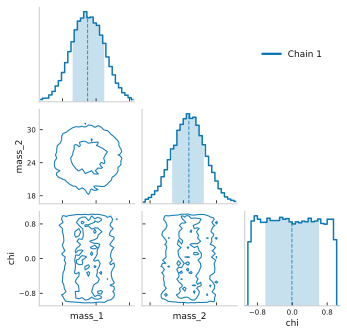

In [11]:
from cornetto import quick_corner

fig, axes = quick_corner(data, chain_labels=["Chain 1"])
plt.show()

## The `Cornetto` class

Use [`Cornetto`](../api.md#cornetto-class) when you want to render multiple figures from the same data - KDEs are computed once and cached.


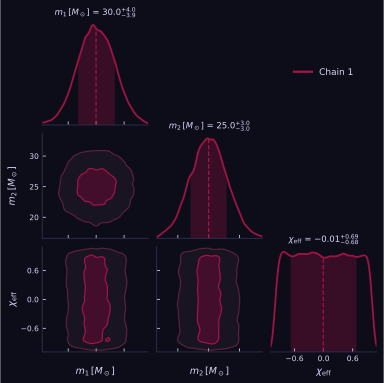

Cornetto setup
--------------
  params         : ['mass_1', 'mass_2', 'chi']
  n_chains       : 1
  chain_labels   : ['Chain 1']
  stat           : median  (center line + shaded interval on 1-D marginals)
  contour sigmas : 1σ→39.3%, 2σ→86.5%
  truths         : none
  ── last plot() ──
  color        : coral
  theme          : dark
  smooth         : True  (KDE if True, histogram if False)
  n_grid         : 128
  bandwidth      : Silverman × 0.8
  fill_1d        : False
  fill_contours  : True


param,chain,median,p16,p84,mean,std
mass_1,Chain 1,29.98,26.08,34,30.02,3.984
mass_2,Chain 1,25,21.96,27.98,25,3.023
chi,Chain 1,-0.007335,-0.683,0.6804,-0.001651,0.5783


In [13]:
from cornetto import Cornetto

c = Cornetto(data, labels=labels, chain_labels=["Chain 1"])
fig, axes = c.plot(color="coral", dark=True)
plt.show()

c.info()      # prints the exact setup used
c.summary()   # summary table (HTML in Jupyter, plain text in terminal)

## Saving

PDF and SVG preserve vector quality for papers and talks.

In [ ]:
fig.savefig("posterior.pdf", bbox_inches="tight")
fig.savefig("posterior.svg", bbox_inches="tight")

## Next steps

- [User guide](../guide.md) — weights, statistics, styling, pairplot.
- [Examples gallery](../generated/gallery/index.md) — marginals, traces, advanced styling.
- [Fast mode](../quick-corner.md) — `quick_corner` in depth.
- [API reference](../api.md) — every parameter documented.